# EDA (Exploratory Data Analysis)

1. Load datasets

2. Clean data(missing values, duplicated, types)

3. Treat outliers

4. Univariate, bivariate & multivariate analysis

5. Insights

### Outlier 

A data point that is significantly different from other data points in a dataset 

#### How outliers occur---?

1. Measurement errors

2. Data entry mistakes

#### Why they are important---?

1. They can be errors

2. They effect the data analysis

#### How to identify the outliers---?

1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization techniques

---> Box Plots

---> Scatter Plots

---> Histograms

### Univariate analysis 

A method that analyses a single variable to describe it's characteristics, find patterns and summarize data.

#### It involves only one variable

### Bivariate analysis

It will give relationship between 2 variables. It helps to find if there is any co-relation, association or connection between 2 variables.

#### It involves 2 variables

### Multivariate analysis

To understand how multiple factors interact and influence each other.

#### It involves more than 2 variables

Example -
How our age, income, and education level together influence the purchasing behaviour


# ETL

# ELT

## EDA : < Dataset >

1. Load and Overview

2. CLeaning (missing, dupes, dtypes)

3. Univariate, Bivariate and Multivariate analysis

4. Outlier - IQR

5. Feature Engineering

6. Key Insights

### Feature Engineering - " F.E is the process of turning raw data into useful features " that helps to improve the performance of machine learning models.

In [2]:
# 1. Load libraries & Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Basic Information and Overview
print("Shape of dataset:",df.shape)
print("\nData Info: \n")
df.info()

#Summary statistics
df.describe(include='all')

Shape of dataset: (891, 15)

Data Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing value analysis
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum()/len(df))*100
})

missing.sort_values(by='missing_percent', ascending=False)

,missing_count,missing_percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000


In [11]:
# 4. Handling Missing Values

# Fill the numeric messing values with the mean

df['age'] = df['age'].fillna(df['age'].mean())

# Fill categorical missing values with mode

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'deck' column (too many missing values)
df.drop(columns=['deck'],inplace=True)

#print("Missing values after cleaning: \n",df.)

KeyError: "['deck'] not found in axis"

Insight : We filled important columns and removed highly missing ones

This keeps maximum information while making the dataset clean

In [10]:
# Duplicate and Data type check

print("Duplicate rows:",df.duplicated().sum())

#Convert some columns to category type
df['class'] = df['class'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

df.info()



Duplicate rows: 111
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(4), object(3)
memory usage: 67.5+ KB


In [ ]:
# 6. Univariate analysis - Numerical Features
num_cols = df.select_dtypes(include=['float','int64']).columns
df[num_cols].describe()

sns.histplot(df)



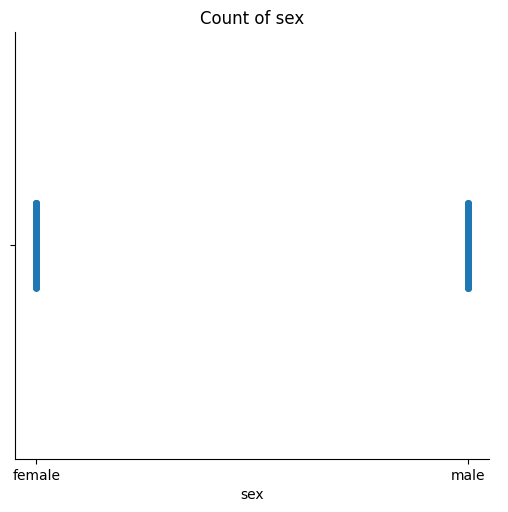

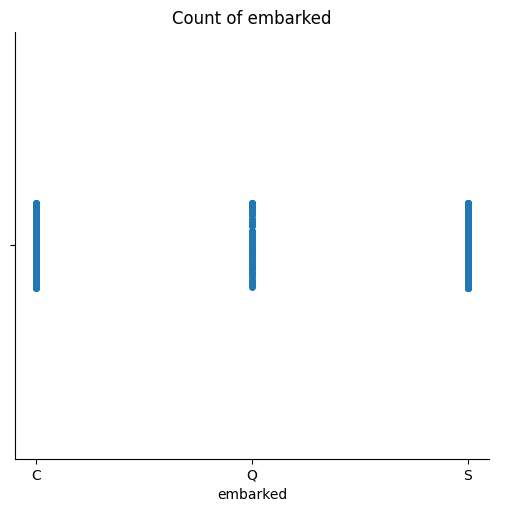

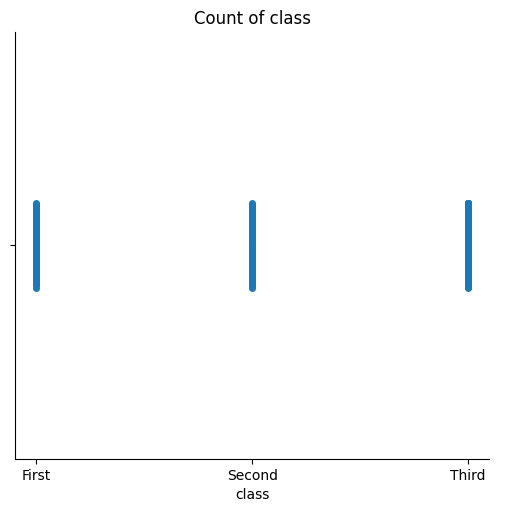

In [13]:
#Univariate Analysis - Categorical Features

cat_clos = df.select_dtypes('category').columns
for col in cat_clos:
    sns.catplot(x=col,data=df)
    plt.title(f"Count of {col}")

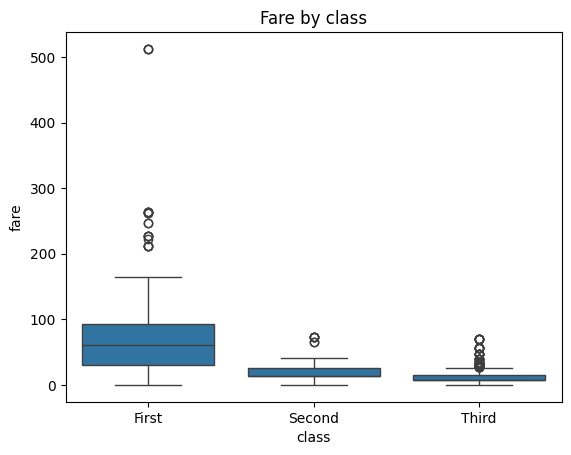

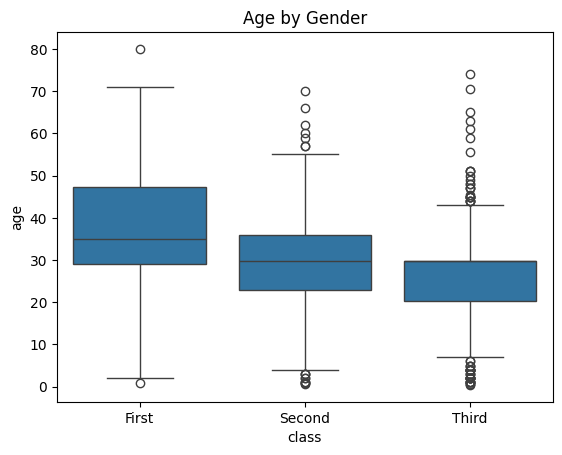

In [15]:
# Bivariate Analysis - Numerical vs Categorical

sns.boxplot(x='class',y='fare',data=df)
plt.title("Fare by class")
plt.show()

sns.boxplot(x='class',y='age',data=df)
plt.title("Age by Gender")
plt.show()


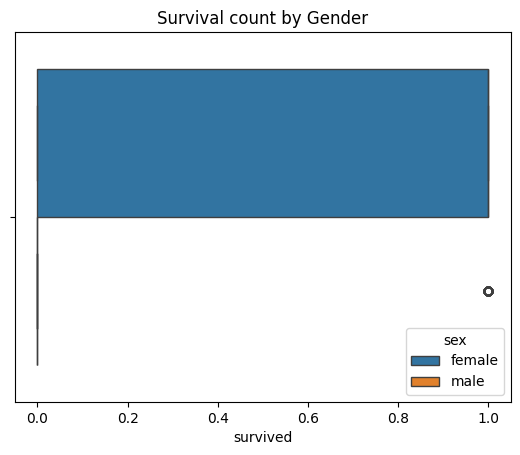

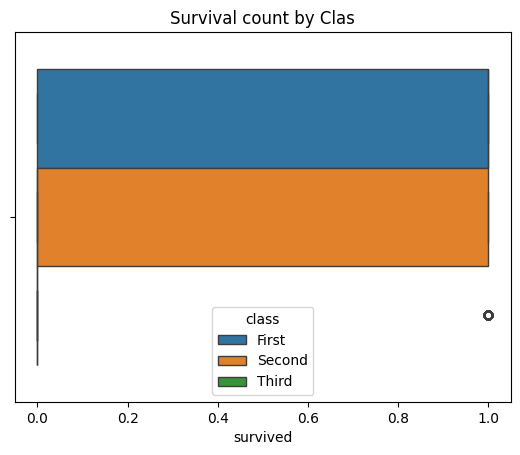

In [16]:
sns.boxplot(x='survived',hue='sex',data=df)
plt.title("Survival count by Gender")
plt.show()

sns.boxplot(x='survived',hue='class',data=df)
plt.title("Survival count by Clas")
plt.show()

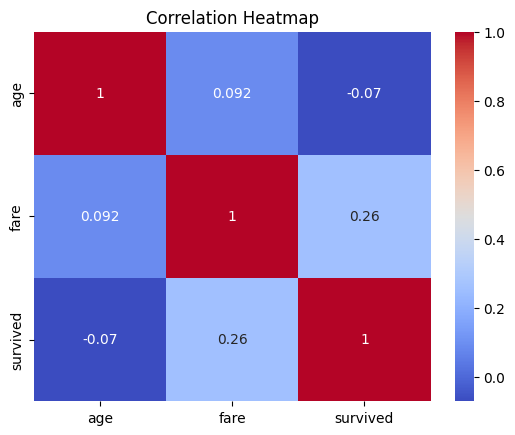

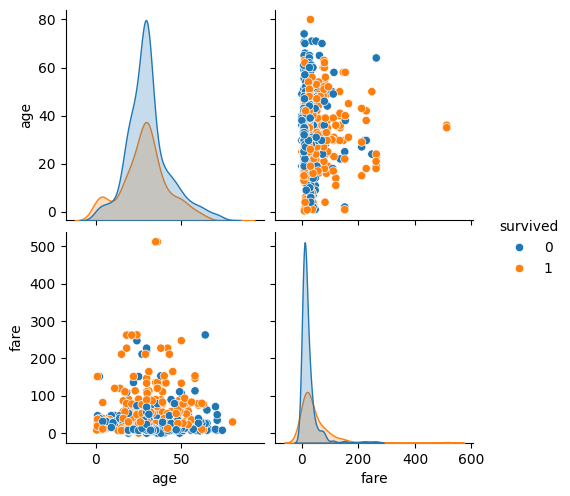

In [18]:
# corelation and multivariate analysis

corr = df[['age','fare','survived']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[['age','fare','survived']], hue='survived')
plt.show()



Insights:

1.Fare has a positive correlation with survival

2.Age has a slightly negative corelation with survival

Number of outliers in fare: 891


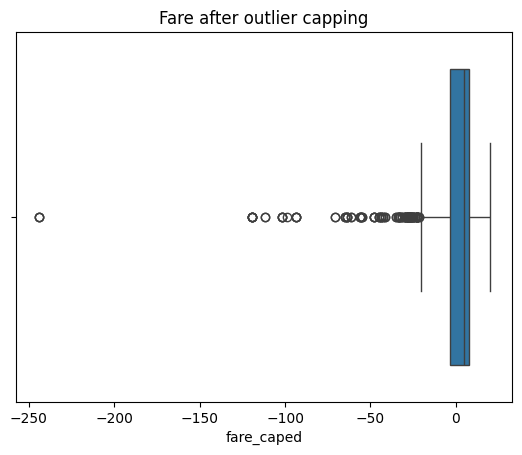

In [21]:
# Outlier Detection using IQR 

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare']
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 - 1.5 * IQR

outliers = df[(df['fare']<lower) | (df['fare']>upper)]

print("Number of outliers in fare:",len(outliers))

df['fare_caped'] = df['fare'].clip(lower,upper)
sns.boxplot(x=df['fare_caped'])
plt.title("Fare after outlier capping")
plt.show()

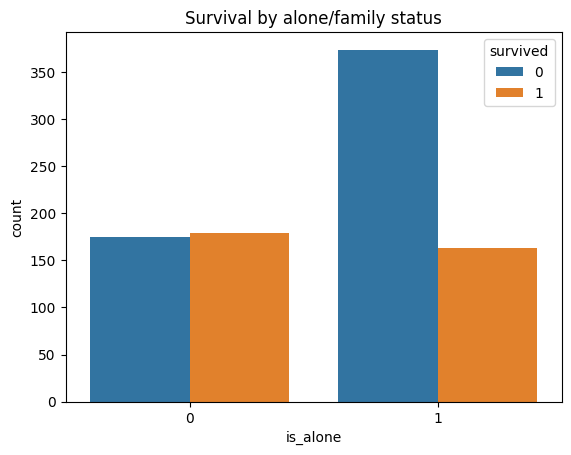

,family_size,is_alone,survived
0,2,0,0
1,2,0,1
2,1,1,1
3,2,0,1
4,1,1,0


In [25]:
# Feature Engineering

# Create new features

df['family_size'] = df['sibsp'] + df['parch'] + 1

df['is_alone'] = (df['family_size'] == 1).astype(int)

sns.countplot(x='is_alone',hue='survived',data=df)
plt.title("Survival by alone/family status")
plt.show()

df[['family_size','is_alone','survived']].head()

In [26]:
# Export the cleaned data
df.to_csv("Titanic_cleaned.csv", index=False)
print("\n Cleaned Titanic data saved as titamic_cleaned.csv")



 Cleaned Titanic data saved as titamic_cleaned.csv


In [27]:
import os
print(os.getcwd())

c:\Users\supev\OneDrive\Desktop\Data Analysis
